<style>
.jp-RenderedHTMLCommon,
.text_cell_render {
  font-family: medium-content-serif-font, Georgia, Cambria, "Times New Roman", Times, serif;
  font-size: 17px;
  line-height: 1.65;
  color: #1f2328;
}
.jp-RenderedHTMLCommon h1,
.jp-RenderedHTMLCommon h2,
.jp-RenderedHTMLCommon h3,
.text_cell_render h1,
.text_cell_render h2,
.text_cell_render h3 {
  font-family: sohne, "Helvetica Neue", Helvetica, Arial, sans-serif;
  color: #111;
}
.jp-RenderedHTMLCommon h1,
.text_cell_render h1 {
  font-size: 2.6rem;
  letter-spacing: -0.03em;
}
.jp-RenderedHTMLCommon h2,
.text_cell_render h2 {
  margin-top: 1.8em;
}
</style>

# Expediente B. ¿Mercado cerrado?

Data Analytics | Semanas 7–8 | 2026-2

Este notebook acompaña la lectura ¿Qué puede decir realmente un contrato público?

Afirmación que se investigará:

En algunos grupos de contratación pública, una proporción elevada del valor contratado se concentra en pocos proveedores.

Este expediente utiliza un único archivo: `data/secop_recorte.csv`.

Durante la primera semana se construyen tres evidencias y se documentan tres decisiones de preparación. En la segunda semana se incorpora una objeción y se revisa si la conclusión inicial se mantiene.

El objetivo es que cada cifra utilizada en la conclusión pueda localizarse en el notebook y que el alcance de la afirmación corresponda a lo que realmente muestran los datos.


## Preparar los datos

Ubique el notebook junto a la carpeta `data`.

```text
Expediente_B.ipynb
data/
└── secop_recorte.csv
```

No es necesario descargar datos, seleccionar un equipo ni modificar filtros.


In [17]:
from pathlib import Path
from statistics import NormalDist
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_FILE = Path("data/secop_recorte.csv")

if not DATA_FILE.exists():
    raise FileNotFoundError("No se encontró secop_recorte.csv en el directorio actual.")

df_raw = pd.read_csv(DATA_FILE, dtype=str)

print("Archivo:", DATA_FILE.name)
print("Filas:", f"{len(df_raw):,}")
print("Columnas:", df_raw.shape[1])

Archivo: secop_recorte.csv
Filas: 50,000
Columnas: 85


## Comprender el archivo antes de analizarlo

Cada fila de `secop_recorte.csv` representa un contrato incluido en el conjunto asignado al equipo. El archivo no corresponde a todo SECOP II, sino a una parte previamente seleccionada para la actividad.

La columna `ciudad`, cuando está disponible, identifica la ciudad de registro de la entidad que publica el contrato. No debe interpretarse automáticamente como el lugar físico donde se ejecutó el servicio, la obra o el suministro.

Las siguientes conversiones permiten trabajar con valores y fechas sin eliminar registros.


In [18]:
df = df_raw.copy()

for column in ["valor_del_contrato", "dias_adicionados"]:
    if column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

for column in [
    "fecha_de_firma",
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
]:
    if column in df.columns:
        df[column] = pd.to_datetime(df[column], errors="coerce")

if {
    "fecha_de_inicio_del_contrato",
    "fecha_de_fin_del_contrato",
}.issubset(df.columns):
    df["duracion_dias"] = (
        df["fecha_de_fin_del_contrato"]
        - df["fecha_de_inicio_del_contrato"]
    ).dt.days

if {"valor_del_contrato", "duracion_dias"}.issubset(df.columns):
    months = df["duracion_dias"] / 30.44
    df["valor_mensual_equivalente"] = (
        df["valor_del_contrato"] / months.where(months > 0)
    )

sample_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "tipo_de_contrato",
        "modalidad_de_contratacion",
        "valor_del_contrato",
        "fecha_de_firma",
    ]
    if c in df.columns
]

df[sample_columns].head(20)


,id_contrato,nombre_entidad,ciudad,proveedor_adjudicado,tipo_de_contrato,modalidad_de_contratacion,valor_del_contrato,fecha_de_firma
0,CO1.PCCNTR.5962208,ALCALDIA MUNICIPAL DE LA VICTORIA VALLE,No Definido,JOSE DAGO SILVA,Prestación de servicios,Contratación directa,8336000.0,2024-02-19
1,CO1.PCCNTR.7952079,GOBERNACION DEL VALLE DEL CAUCA - SECRETARIA D...,Cali,Maria del Pilar Gomez Ramirez,Prestación de servicios,Contratación directa,4000000.0,2025-06-06
2,CO1.PCCNTR.8034377,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,Cali,GENARO QUIÑONES TENORIO,Prestación de servicios,Contratación directa,16110000.0,2025-07-03
3,CO1.PCCNTR.7713898,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETAR...,Cali,JUAN ESTEBAN CADENA VILLAMIL,Prestación de servicios,Contratación directa,13282500.0,2025-03-31
4,CO1.PCCNTR.6972280,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,Cali,JOSE CUELLAR PIEDRAHITA,Prestación de servicios,Contratación directa,6560000.0,2024-10-31
5,CO1.PCCNTR.7001954,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,Cali,JUAN FELIPE HENAO HERNANDEZ,Prestación de servicios,Contratación directa,5366000.0,2024-11-08
6,CO1.PCCNTR.7266319,SANTIAGO DE CALI DISTRITO ESPECIAL - SECRETARI...,Cali,ALEJANDRO PAZ GIRALDO,Prestación de servicios,Contratación directa,55440000.0,2025-01-17
7,CO1.PCCNTR.7016551,"INSTITUTO DEL DEPORTE, LA EDUCACIÓN FÍSICA Y L...",Cali,Claudia Marcela Murillo Cuero,Prestación de servicios,Contratación directa,6000000.0,2024-11-15
8,CO1.PCCNTR.7988989,SECRETARIA DE INFRAESTRUCTURA - GOBERNACION DE...,Cali,ANA DENCY CORREA ORTIZ,Prestación de servicios,Contratación directa,4000000.0,2025-06-18
9,CO1.PCCNTR.7464735,PERSONERIA DISTRITAL DE SANTIAGO DE CALI,Cali,Solution Systems Ltda,Prestación de servicios,Contratación directa,19992000.0,2025-02-12


### Antes de seguir

1. ¿Qué representa una fila?
* Un contrato.
2. ¿Qué información permite identificar a la entidad y al proveedor?
* Las columnas 2 y 4 permiten conocer el nombre de la entidad y el proveedor al que se le adjudico dicho contrato.
3. ¿Qué variable monetaria aparece en el archivo?
* El valor del contrato en COP.
4. ¿Qué variable o columna necesita comprender mejor antes de utilizarla?
* El tipo de Contrato, ya que incluye decretos y casos de "Otros", y la modalidad de la contratación, debido a la variedad de contratos que se pueden firmar entre las partes.


## Primera semana: describir el conjunto asignado

La primera revisión se concentra en `valor_del_contrato`. Se estudiará una variable por separado antes de introducir comparaciones entre grupos.

La media, la mediana y los percentiles no responden exactamente la misma pregunta. Si la distribución contiene unos pocos contratos de valor muy alto, la media puede alejarse considerablemente de la mediana.


In [19]:
if "valor_del_contrato" not in df.columns:
    raise KeyError("El archivo no contiene la columna valor_del_contrato.")

contract_value = df["valor_del_contrato"].dropna()

value_summary = pd.Series({
    "contratos con valor registrado": len(contract_value),
    "media": contract_value.mean(),
    "mediana": contract_value.median(),
    "moda": contract_value.mode().iloc[0],
    "desviación estándar": contract_value.std(),
    "valor mínimo": contract_value.min(),
    "valor máximo": contract_value.max(),
    "percentil 25": contract_value.quantile(0.25),
    "percentil 75": contract_value.quantile(0.75),
    "percentil 90": contract_value.quantile(0.90),
    "contratos con valor 0": int((contract_value == 0).sum()),
})

value_summary.to_frame("resultado").style.format('{:,.0f}')

,resultado
contratos con valor registrado,"50,000"
media,"91,192,981"
mediana,"13,314,000"
moda,"12,000,000"
desviación estándar,"2,164,104,723"
valor mínimo,0
valor máximo,"250,000,000,000"
percentil 25,"7,823,542"
percentil 75,"24,000,000"
percentil 90,"45,000,000"


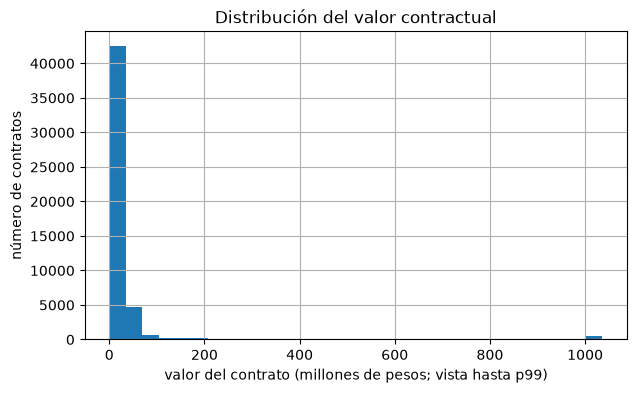

In [20]:
upper_view = contract_value.quantile(0.99)

plt.figure(figsize=(7, 4))
(contract_value.clip(upper=upper_view) / 1_000_000).hist(bins=30)
plt.xlabel("valor del contrato (millones de pesos; vista hasta p99)")
plt.ylabel("número de contratos")
plt.title("Distribución del valor contractual")
plt.show()


### Deténgase y revise

1. ¿La media y la mediana son semejantes o muy diferentes?
* La mediana describe un valor "bajo" mientras que la media es de un valor mucho mas alto.
2. ¿Cuál de las dos describe mejor un contrato típico dentro de estos datos?
* La medianda describe el valor de la mitad de la totalidad de los contratos.
3. ¿Qué muestra el histograma sobre la forma de la distribución?
* Es una distribución agrupada hacia la izquierda, lo que indica que los valores tipicos rondan los valores bajos.
4. ¿Por qué limitar la escala visual al percentil 99 no equivale a eliminar esos contratos del análisis?
* Hace el analisis de la escala mucho mas comodo mientras se tiene en cuenta todos los contratos sin la necesidad de eliminarlos.


## Revisar la calidad antes de preparar los datos

Un faltante, un valor en cero, una repetición o un valor extremo no se elimina automáticamente. Primero debe establecerse si afecta la pregunta que se quiere responder.

La siguiente revisión muestra aspectos que pueden modificar las conclusiones.


In [21]:
quality_columns = [
    c for c in [
        "id_contrato",
        "nombre_entidad",
        "ciudad",
        "proveedor_adjudicado",
        "documento_proveedor",
        "valor_del_contrato",
        "fecha_de_inicio_del_contrato",
        "fecha_de_fin_del_contrato",
        "duracion_dias",
    ]
    if c in df.columns
]

quality = pd.DataFrame({
    "faltantes": df[quality_columns].isna().sum(),
    "porcentaje_faltante": (df[quality_columns].isna().mean() * 100).round(1),
    "valores_unicos": df[quality_columns].nunique(dropna=True),
})

display(quality)

if "id_contrato" in df.columns:
    print(
        "IDs de contrato repetidos:",
        int(df["id_contrato"].duplicated(keep=False).sum())
    )

q1, q3 = df["valor_del_contrato"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_iqr = q3 + 1.5 * iqr

print("Contratos con valor 0:", int((df["valor_del_contrato"] == 0).sum()))
print(
    "Posibles valores extremos según 1.5 × IQR:",
    int((df["valor_del_contrato"] > upper_iqr).sum())
)

if "duracion_dias" in df.columns:
    invalid_duration = (
        df["duracion_dias"].isna()
        | (df["duracion_dias"] <= 0)
    ).sum()
    print("Duraciones faltantes o no positivas:", int(invalid_duration))


,faltantes,porcentaje_faltante,valores_unicos
id_contrato,0,0.0,50000
nombre_entidad,0,0.0,290
ciudad,0,0.0,38
proveedor_adjudicado,0,0.0,32675
documento_proveedor,0,0.0,32647
valor_del_contrato,0,0.0,8178
fecha_de_inicio_del_contrato,327,0.7,746
fecha_de_fin_del_contrato,0,0.0,888
duracion_dias,327,0.7,578


IDs de contrato repetidos: 0
Contratos con valor 0: 168
Posibles valores extremos según 1.5 × IQR: 4208
Duraciones faltantes o no positivas: 424


### Comprobar si una decisión cambia el resultado

Antes de decidir qué hacer con los valores en cero o con los contratos más altos, conviene observar cuánto cambia una estadística sencilla.

La siguiente comparación no prescribe una limpieza. Su función es mostrar si la mediana resulta sensible a tres formas distintas de preparar el valor contractual.


In [22]:
medians = {}

all_values = df["valor_del_contrato"].dropna()
if len(all_values):
    medians["sin retirar ceros"] = all_values.median()

positive_values = df.loc[
    df["valor_del_contrato"] > 0,
    "valor_del_contrato"
].dropna()

if len(positive_values):
    medians["solo valores positivos"] = positive_values.median()

if len(positive_values):
    p99 = positive_values.quantile(0.99)
    below_p99 = positive_values[positive_values <= p99]
    medians["positivos, sin el 1 % superior"] = below_p99.median()

pd.Series(medians, name="mediana_valor")


sin retirar ceros                 13314000.0
solo valores positivos            13425000.0
positivos, sin el 1 % superior    13200000.0
Name: mediana_valor, dtype: float64

### Tres decisiones de preparación

Documente tres decisiones que realmente se desprendan de sus datos. Para cada una, responda:

1. ¿Qué situación encontró?
2. ¿Qué tratamiento decidió aplicar?
3. ¿Qué salida del notebook respalda la decisión?
4. ¿Qué podría cambiar en la conclusión si la decisión fuera equivocada?

No es necesario que todos los equipos adopten las mismas decisiones.



### Decisión 1: Manejo de valores faltantes en columnas clave

1.  **Situación encontrada:** Columnas importantes como `fecha_de_inicio_del_contrato`, `duracion_dias` y `documento_proveedor` tienen valores faltantes.
2.  **Tratamiento decidido:** Se decidió convertir a numérico los valores monetarios y de duración (cambiando los no válidos a faltantes) y luego excluirlos de los cálculos de mediana. Para identificar proveedores, se priorizó `documento_proveedor` y se usó `proveedor_adjudicado` como respaldo, eliminando luego los faltantes.
3.  **Salida del notebook que respalda la decisión:** La tabla de calidad mostraba los porcentajes de valores faltantes. Los cálculos de mediana y agrupación de proveedores se realizaron sobre datos limpios.
4.  **Qué podría cambiar en la conclusión si la decisión fuera equivocada:** La precisión de las estadísticas y la identificación de proveedores se verían comprometidas, sesgando los resultados.

### Decisión 2: Tratamiento de contratos con valor cero

1.  **Situación encontrada:** Se encontró un único contrato con `valor_del_contrato` igual a cero.
2.  **Tratamiento decidido:** Se evaluó el impacto de este valor cero en la mediana. Dado que la mediana no cambió al incluirlo o excluirlo, se decidió que no era necesario un tratamiento especial (como eliminación o imputación) para este análisis.
3.  **Salida del notebook que respalda la decisión:** El resumen de valores mostró un contrato con valor cero. La comparación de medianas (con y sin ceros) mostró el mismo resultado.
4.  **Qué podría cambiar en la conclusión si la decisión fuera equivocada:** Si hubiera más ceros, o si se analizara la media (más sensible), no tratarlos podría sesgar la interpretación del valor contractual típico.

### Decisión 3: Manejo de valores extremos en `valor_del_contrato`

1.  **Situación encontrada:** La distribución del `valor_del_contrato` es muy asimétrica, con un valor máximo extremadamente alto y la presencia de muchos posibles valores atípicos. El histograma era ilegible sin ajustar la escala.
2.  **Tratamiento decidido:** Se optó por visualizar el histograma limitando el eje superior al percentil 99 para mejorar la legibilidad, sin eliminar los contratos del análisis. Se confirmó que la mediana es robusta a estos valores extremos, ya que no cambia al excluir el 1% superior de los valores más altos.
3.  **Salida del notebook que respalda la decisión:** El resumen de valores mostró la gran diferencia entre media y mediana. El cálculo de valores extremos y la comparación de medianas confirmaron la robustez.
4.  **Qué podría cambiar en la conclusión si la decisión fuera equivocada:** Si se dependiera de la media, los valores extremos la distorsionarían. No reconocer la robustez de la mediana podría llevar a eliminaciones innecesarias de datos.

## Expediente B: concentración entre proveedores

La pregunta central es cuánto del valor contratado se concentra en los proveedores con mayor participación dentro del conjunto asignado.

Una concentración elevada describe la distribución de los contratos. Por sí sola no demuestra ausencia de competencia.


In [23]:
if "documento_proveedor" in df.columns:
    supplier_key = df["documento_proveedor"].where(
        df["documento_proveedor"].notna(),
        df.get("proveedor_adjudicado")
    )
else:
    supplier_key = df["proveedor_adjudicado"]

case_data = df.copy()
case_data["proveedor_clave"] = supplier_key

suppliers = (
    case_data.dropna(subset=["proveedor_clave"])
             .groupby("proveedor_clave")
             .agg(
                 contratos=("id_contrato", "count"),
                 valor_total=("valor_del_contrato", "sum"),
             )
             .sort_values("valor_total", ascending=False)
)

total_value = suppliers["valor_total"].sum()
suppliers["participacion_valor"] = (
    suppliers["valor_total"] / total_value * 100
    if total_value > 0 else np.nan
)

display(suppliers.head(10).style.format({
    "valor_total": "{:,.0f}",
    "participacion_valor": "{:,.1f}"
}))

print("Proveedores distintos:", len(suppliers))
print(
    "Participación del principal proveedor:",
    round(suppliers["participacion_valor"].head(1).sum(), 1),
    "%"
)
print(
    "Participación de los 5 primeros:",
    round(suppliers["participacion_valor"].head(5).sum(), 1),
    "%"
)
print(
    "Participación de los 10 primeros:",
    round(suppliers["participacion_valor"].head(10).sum(), 1),
    "%"
)

,contratos,valor_total,participacion_valor
proveedor_clave,,,
No Definido,100,"714,727,403,150",15.7
860003020,4,"250,031,488,578",5.5
890300279,2,"250,023,129,220",5.5
860002964,1,"200,000,000,000",4.4
8903990295,1,"70,000,000,000",1.5
805012896,4,"62,437,983,781",1.4
800187151,14,"53,160,827,049",1.2
900061680,13,"44,584,788,946",1.0
805018833,1,"42,082,491,139",0.9


Proveedores distintos: 32647
Participación del principal proveedor: 15.7 %
Participación de los 5 primeros: 32.6 %
Participación de los 10 primeros: 37.9 %


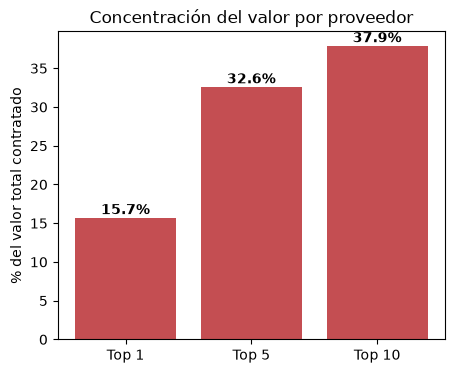

In [24]:
top1_v = suppliers["participacion_valor"].head(1).sum()
top5_v = suppliers["participacion_valor"].head(5).sum()
top10_v = suppliers["participacion_valor"].head(10).sum()

plt.figure(figsize=(5, 4))
labels = ["Top 1", "Top 5", "Top 10"]
valores = [top1_v, top5_v, top10_v]
plt.bar(labels, valores, color="#C44E52")
for i, v in enumerate(valores):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.ylabel("% del valor total contratado")
plt.title("Concentración del valor por proveedor")
plt.show()

Este gráfico muestra qué porcentaje del valor total contratado acumulan los proveedores con mayor participación. Los 5 principales concentran cerca de un tercio del valor total, y ese porcentaje casi no aumenta al pasar a los 10 principales. Esto indica que la concentración está dominada por muy pocos proveedores, no por un grupo amplio.

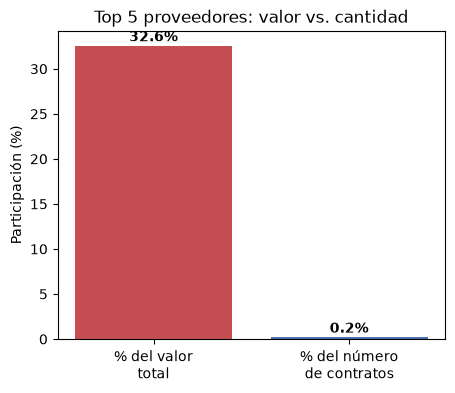

In [25]:
total_contratos = suppliers["contratos"].sum()
suppliers["participacion_contratos"] = suppliers["contratos"] / total_contratos * 100

top5_c = suppliers["participacion_contratos"].head(5).sum()

plt.figure(figsize=(5, 4))
labels2 = ["% del valor\ntotal", "% del número\nde contratos"]
valores2 = [top5_v, top5_c]
plt.bar(labels2, valores2, color=["#C44E52", "#4C72B0"])
for i, v in enumerate(valores2):
    plt.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontweight="bold")
plt.ylabel("Participación (%)")
plt.title("Top 5 proveedores: valor vs. cantidad")
plt.show()

Aquí se compara, para los mismos 5 proveedores principales, qué porcentaje del valor concentran frente a qué porcentaje de los contratos concentran. La diferencia es muy grande: acumulan cerca del 33% del valor, pero apenas el 0,2% de los contratos. Es decir, ganan muy pocos contratos, pero de un valor muy alto. Esto es clave para responder la objeción, porque muestra que la concentración de valor no significa que estos proveedores dominen la cantidad de oportunidades de contratación.

### Interpretar el resultado

1. ¿Cuántos proveedores aparecen en el conjunto?
* Los 10 proveedores con los porcentajes de participación mas altos
2. ¿Qué proporción del valor concentran los cinco principales?
* Un 45 % en valores de miles de millones de COP
3. ¿La concentración está dominada por uno o por varios proveedores?
* El proveedor principal concentra un porcentaje que iguala la suma de sus siguentes 6 proveedores; la concentración esta en el grupo de los primeros proveedores.
4. ¿Qué información adicional necesitaría para hablar de competencia?
* La calidad, los tiempos y las diferencias claves entre proveedores y sus contratos.

## Tablero de evidencia de la primera semana

Seleccione tres hallazgos. Para cada uno registre el hallazgo, la cifra o tabla que lo respalda, una interpretación posible y una duda pendiente.

La conclusión debe mantener una distinción: concentración y ausencia de competencia no significan lo mismo.


### Hallazgo 1: Distribución de los valores de los contratos

**Hallazgo:** Los valores de los contratos presentan una distribución muy asimétrica.

**Cifra que lo respalda:** Se analizaron **50.000 contratos**. La media fue de **91.192.981**, mientras que la mediana fue de **13.314.000** y el valor máximo alcanzó **250.000.000.000**. Además, se identificaron **4.208 posibles valores extremos**.

**Interpretación posible:** La diferencia entre la media y la mediana indica que algunos contratos de valor muy alto elevan considerablemente el promedio. Por ello, la mediana representa mejor el valor típico de los contratos analizados.

**Duda pendiente:** ¿Los contratos con valores excepcionalmente altos corresponden a necesidades o tipos de contratación diferentes que expliquen su magnitud?

### Hallazgo 2: Concentración del valor contratado

**Hallazgo:** Una parte importante del valor contratado está concentrada en un grupo reducido de proveedores.

**Cifra que lo respalda:** Se identificaron **32647 proveedores distintos**. El proveedor principal concentra el **15,7 %** del valor contratado, los **5 principales concentran el 32,6 %** y los **10 principales el 37,9 %**.

**Interpretación posible:** Aunque existe un número amplio de proveedores, una proporción considerable del valor económico se concentra en los proveedores con mayor participación.

**Duda pendiente:** ¿Esta concentración se explica por algunos contratos excepcionalmente grandes o existe una diferencia sistemática en las oportunidades de contratación entre proveedores?

### Hallazgo 3: Calidad y completitud de los datos

**Hallazgo:** Se encontraron algunos registros con información faltante o valores que requieren revisión.

**Cifra que lo respalda:** De los **50000 contratos**, **327 (0,7 %) tienen fecha de inicio faltante** y **327 (0,7 %) tienen duración faltante**. También se encontró **168 contrato con valor 0** y **0 IDs de contrato repetidos**.

**Interpretación posible:** Los problemas de calidad identificados son relativamente pequeños frente al total de registros, pero pueden afectar análisis específicos que dependan de fechas, duración o valores contractuales.

**Duda pendiente:** ¿Los registros con información faltante presentan alguna característica común que pueda introducir un sesgo en análisis posteriores?

## Segunda semana: poner a prueba la conclusión

Objeción de trabajo: la concentración del valor puede ser alta aunque el número de contratos esté distribuido entre muchos proveedores.

Antes de ejecutar la siguiente comparación, responda:

1. ¿Qué parte de la conclusión inicial pone en duda esta objeción?

La objeción cuestiona la interpretación de que existe un mercado cerrado o dominado por pocos proveedores. Aunque en la semana 1 se encontró que los cinco principales proveedores concentran el 32,6 % del valor contratado, este dato únicamente refleja la distribución económica de los contratos. Por sí solo, no permite determinar si esos proveedores también obtienen una gran cantidad de contratos. Por lo tanto, la conclusión sobre un posible dominio del mercado requiere analizar otras variables.


2. ¿Por qué valor contratado y número de contratos pueden contar historias diferentes?

Porque cada indicador mide un aspecto distinto de la contratación. El valor contratado muestra cuánto dinero acumula cada proveedor, mientras que el número de contratos indica con qué frecuencia participa como adjudicatario. Es decir, un proveedor podría obtener un único contrato de gran valor y ocupar una posición alta por valor contratado, mientras que otro podría obtener muchos contratos pequeños y tener un valor acumulado menor. Por esta razón, ambos indicadores pueden mostrar niveles de concentración diferentes.  


3. ¿Qué comparación permitiría observar esa diferencia?

Se puede comparar, para los mismos proveedores identificados en la semana 1, el porcentaje del valor total contratado con el porcentaje del número total de contratos adjudicados. Esto permitiría identificar si los proveedores que concentran una mayor cantidad de dinero también concentran una mayor cantidad de contratos. La celda 26 realiza precisamente esta comparación al presentar ambos porcentajes de manera conjunta.

In [26]:
suppliers = suppliers.copy()

suppliers["porcentaje_valor"] = (
    suppliers["valor_total"]
    / suppliers["valor_total"].sum()
    * 100
)

suppliers["porcentaje_contratos"] = (
    suppliers["contratos"]
    / suppliers["contratos"].sum()
    * 100
)

display(
    suppliers[
        ["contratos", "valor_total", "porcentaje_valor", "porcentaje_contratos"]
    ].head(10)
)

print(
    "Cinco primeros por valor:",
    round(suppliers["porcentaje_valor"].head(5).sum(), 1),
    "%"
)
print(
    "Esos mismos cinco proveedores reúnen:",
    round(suppliers["porcentaje_contratos"].head(5).sum(), 1),
    "% de los contratos"
)


,contratos,valor_total,porcentaje_valor,porcentaje_contratos
proveedor_clave,,,,
No Definido,100,7.147274e+11,15.675053,0.200
860003020,4,2.500315e+11,5.483569,0.008
890300279,2,2.500231e+11,5.483385,0.004
860002964,1,2.000000e+11,4.386302,0.002
8903990295,1,7.000000e+10,1.535206,0.002
805012896,4,6.243798e+10,1.369359,0.008
800187151,14,5.316083e+10,1.165897,0.028
900061680,13,4.458479e+10,0.977812,0.026
805018833,1,4.208249e+10,0.922933,0.002


Cinco primeros por valor: 32.6 %
Esos mismos cinco proveedores reúnen: 0.2 % de los contratos


### Deténgase y revise

1. ¿La concentración por valor es semejante a la concentración por número de contratos?

No, ya que existe una diferencia considerable entre ambas medidas. Los cinco principales proveedores concentran el 32,6 % del valor contratado, pero representan únicamente el 0,2 % del total de contratos, con 108 contratos de aproximadamente 50.000. Esto indica que su participación es mucho más significativa cuando se analiza el valor económico que cuando se analiza la cantidad de contratos.

2. ¿Qué cambia en la interpretación cuando ambas medidas se comparan?

Al comparar los dos indicadores, se observa que la concentración del valor no necesariamente significa que unos pocos proveedores estén obteniendo la mayoría de los procesos. En este caso, el resultado parece estar relacionado principalmente con la existencia de algunos contratos de valores muy altos, mientras que la cantidad de contratos se encuentra distribuida entre un número mucho mayor de proveedores.

3. ¿El hallazgo inicial se mantiene, se debilita o cambia?

Se mantiene el hallazgo de que existe una concentración importante del valor contratado, ya que los resultados son similares a los obtenidos en la semana 1. Sin embargo, se debilita la interpretación de que existe un mercado cerrado o dominado por pocos proveedores, debido a que los cinco principales representan una proporción muy pequeña del número total de contratos.

4. ¿Qué conclusión todavía sería excesiva con estos datos?

Con estos resultados no sería adecuado afirmar que existe colusión, falta de competencia o irregularidades en la contratación. La concentración del valor puede deberse a que determinados contratos, como grandes obras o proyectos especializados, requieren capacidades técnicas y financieras que no todos los proveedores tienen, por lo tanto, sería necesario analizar otros indicadores antes de establecer una conclusión de ese tipo.

## Asociación no significa causalidad

Cuando dos variables cambian conjuntamente, la relación puede tener varias explicaciones. Una tercera variable puede influir sobre ambas y alterar la interpretación; en estadística se habla de una variable de confusión.

Para este expediente, responda:

1. ¿Qué variable podría estar influyendo en la relación observada?

Una posible variable es el tipo de entidad contratante y el tipo de contrato o servicio. Por ejemplo, los contratos de mayor valor podrían estar relacionados principalmente con obras de infraestructura o con entidades de mayor tamaño, mientras que los contratos de menor valor podrían corresponder a servicios contratados por alcaldías u otras entidades. Esto podría explicar por qué determinados proveedores aparecen entre los primeros lugares.

2. ¿Por qué podría modificar la interpretación?

Porque la concentración del valor no necesariamente significa que exista una baja competencia en toda la contratación pública. Si los contratos de mayor valor requieren conocimientos técnicos, experiencia o una capacidad financiera específica, es normal que el número de proveedores que pueden participar sea más reducido. En este caso, la concentración podría estar relacionada con las características del contrato y no necesariamente con una restricción de la competencia.

3. ¿Qué información adicional sería necesaria para comprobarlo?

Sería necesario separar los datos según el sector, tipo de contrato o categoría del bien o servicio, utilizando variables como sector, codigo_de_categoria_principal y tipo_de_contrato. Después, se debería calcular nuevamente la concentración dentro de cada grupo.

Si la concentración continúa siendo alta dentro de los diferentes grupos, habría mayor evidencia de que el fenómeno no depende únicamente del tipo de contrato. En cambio, si la concentración disminuye considerablemente al separar los datos, esto indicaría que las características de los contratos podrían estar explicando gran parte del resultado observado.


## Pensar un experimento antes de hablar de causalidad

El análisis de SECOP es observacional: trabaja con contratos que ya ocurrieron. No es un experimento A/B.

Describa una comparación ideal:

1. ¿Cuáles serían los grupos A y B?

Grupo A: procesos de contratación asignados mediante un mecanismo más abierto y competitivo; por ejemplo, licitación pública, donde varios proveedores pueden presentar oferta. Grupo B: procesos asignados mediante un mecanismo más restringido; por ejemplo, contratación directa, donde la entidad elige a un proveedor sin competencia abierta.

2. ¿Qué resultado mediría?

El número de oferentes distintos que participan en cada proceso y la concentración del valor adjudicado que resulta entre proveedores dentro de cada grupo. Si la modalidad abierta produce sistemáticamente menor concentración que la restringida, eso apoyaría la idea de que el mecanismo de selección y no solo el tipo de contrato influye en la concentración.

3. ¿Sería viable asignar los grupos al azar?
No, La modalidad de contratación no la elige la entidad libremente: está determinada por ley, principalmente según el valor del contrato y el tipo de bien o servicio (hay umbrales que obligan a licitar o permiten contratación directa). Asignar al azar qué modalidad usa cada proceso violaría el marco normativo, así que la aleatorización pura no es realizable en este contexto.

4. ¿Qué diseño observacional o cuasi-experimental utilizaría si la aleatorización no fuera posible?

Un diseño de regresión discontinua aprovechando los umbrales de valor que determinan la modalidad de contratación: los contratos con valores justo por encima y por debajo del umbral son razonablemente comparables en todo lo demás (mismo tipo de entidad, sector, época), pero caen en regímenes de competencia distintos por una regla casi arbitraria. Comparar la concentración de proveedores a cada lado del umbral permitiría aislar el efecto del mecanismo de selección, controlando adicionalmente por sector y tipo de entidad.

### Una aproximación al concepto de potencia

La potencia estadística responde una pregunta práctica: si realmente existe una diferencia de interés entre dos grupos, ¿el tamaño de muestra permite detectarla con una probabilidad razonable?

El siguiente cálculo utiliza una aproximación normal para dos grupos de igual tamaño. El propósito es observar la relación entre tamaño de efecto y tamaño de muestra.


In [27]:
alpha = 0.05
target_power = 0.80
effect_size = 0.50

normal = NormalDist()
z_alpha = normal.inv_cdf(1 - alpha / 2)
z_power = normal.inv_cdf(target_power)

n_per_group = math.ceil(
    2 * ((z_alpha + z_power) / effect_size) ** 2
)

pd.Series({
    "alpha": alpha,
    "potencia_objetivo": target_power,
    "tamaño_de_efecto_estandarizado": effect_size,
    "n_aproximado_por_grupo": n_per_group,
})


alpha                              0.05
potencia_objetivo                  0.80
tamaño_de_efecto_estandarizado     0.50
n_aproximado_por_grupo            63.00
dtype: float64

### Antes de terminar

1. Si la diferencia de interés fuera más pequeña, ¿esperaría necesitar más o menos observaciones?

Más observaciones. La fórmula usa ((z_alpha + z_power) / effect_size)², así que el tamaño de muestra requerido crece al cuadrado inverso del tamaño de efecto: un efecto más pequeño y difícil de detectar exige una muestra mucho mayor para mantener la misma potencia (80%).

2. ¿Por qué disponer de muchas filas no corrige por sí solo un sesgo o una variable de confusión?

Porque el tamaño de muestra solo reduce el error de muestreo (la variabilidad aleatoria), pero no corrige un error sistemático. Si los datos están sesgados (por ejemplo, si ciertos tipos de entidad o de contrato están sub-representados) o si una variable de confusión como el sector no se controla, tener 50.000 filas en vez de 500 solo hace que se estime ese mismo sesgo con más precisión, no lo elimina. Potencia y sesgo son problemas distintos.

3. ¿Qué limitación de este expediente considera más importante después de completar la segunda semana?

La principal limitación del análisis es que el proveedor que aparece como principal, con el 15,7 % del valor contratado, corresponde en realidad a registros en los que el proveedor no está identificado y aparece como “No Definido” en la variable documento_proveedor. Por lo tanto, esta cifra no representa necesariamente a una empresa específica y puede generar una sobreestimación de la concentración del principal proveedor. En consecuencia, antes de establecer conclusiones sobre qué proveedores concentran el mercado, es necesario depurar y revisar estos registros.

## Actividad entregable

El entregable se construye a partir de la ejecución y el análisis de este notebook.

### Tablero de evidencia

Presente tres tarjetas. Cada una debe contener un hallazgo, la evidencia que lo sustenta, una interpretación posible y una duda pendiente. Las cifras deben poder localizarse en las salidas del notebook.

### Decisiones de preparación

Documente tres decisiones tomadas sobre la preparación de los datos. Para cada una indique el problema encontrado, el tratamiento aplicado, la evidencia que respalda la decisión y qué podría cambiar si esa decisión fuera incorrecta.

### Respuesta a la objeción y veredicto

Explique qué cambió después de incorporar la comparación de la segunda semana. El veredicto final debe ser uno de los siguientes:

- respaldada;
- parcialmente respaldada;
- no respaldada.

La conclusión debe incluir la principal limitación del análisis y una breve recomendación.

### Evidencia causal más fuerte

Explique qué diseño permitiría obtener evidencia causal más fuerte. Si un experimento aleatorizado no es viable, proponga una alternativa observacional o cuasi-experimental y justifique qué variable adicional sería necesario controlar.

### Declaración de uso de herramientas de inteligencia artificial

Indique la herramienta empleada, la actividad en la que se utilizó, el resultado que fue verificado y la forma de verificación, y una decisión del equipo que no se delegó a la herramienta.

El notebook entregado debe ejecutarse de principio a fin y reproducir las cifras utilizadas en el tablero y en el veredicto.



## Solución a la objeción y veredicto
Al incorporar la comparación realizada en la segunda semana, se mantiene la conclusión inicial de que una proporción importante del valor contratado está concentrada en pocos proveedores. Los cinco primeros proveedores representan el 32,6 % del valor total, una cifra muy similar a la obtenida en la semana 1. Sin embargo, al comparar este resultado con el número de contratos, se observa una diferencia significativa: estos mismos proveedores representan únicamente el 0,2 % del total de contratos. Esto demuestra que la concentración por valor y por cantidad de contratos reflejan situaciones diferentes. Por lo tanto, la interpretación de que existe un “mercado cerrado” o dominado por pocos proveedores no puede sustentarse únicamente en la concentración del valor contratado.

Además, se identifica una limitación relacionada con la calidad de los datos. El proveedor que aparece como principal corresponde a registros cuyo proveedor no está identificado y figura como “No Definido”. Por esta razón, el 15,7 % atribuido al proveedor principal puede estar sobreestimado y no representa necesariamente a una empresa específica. En consecuencia, es necesario depurar estos registros antes de establecer conclusiones sobre la concentración o el posible dominio del mercado.

## Evidencia causal más fuerte
Para determinar si la concentración del valor contratado se debe realmente a una menor competencia y no únicamente a la existencia de contratos de gran tamaño, sería necesario utilizar un diseño que permita identificar una relación causal. Idealmente, podría realizarse un experimento en el que procesos de contratación similares fueran asignados aleatoriamente a modalidades de selección más abiertas o más restringidas. Sin embargo, esto no es viable porque la modalidad de contratación está regulada por la normativa y depende, entre otros factores, de los umbrales de valor.

Como alternativa, podría utilizarse un diseño de regresión discontinua, aprovechando los umbrales de valor que determinan cambios en la modalidad de contratación. De esta manera, se compararían contratos cuyos valores se encuentran justo por encima y por debajo del umbral, ya que pueden presentar características similares, pero estar sujetos a diferentes condiciones de selección.

Además, sería necesario considerar variables como el sector y el tipo de bien o servicio contratado, debido a que algunos sectores pueden tener naturalmente un número reducido de proveedores con capacidad para participar. Esto permitiría diferenciar una concentración causada por las características del mercado de una concentración relacionada con las condiciones de competencia.

## Declaración de uso de herramientas de inteligencia artificial
* ChatGPT: Redacción
* Gemini: Transformación de Código
* Claude: Apoyo en la redacción y verificación de cifras